In [1]:
from typing import TypedDict, Annotated, Literal, Dict, Any
from langgraph.graph import StateGraph, END
import json

# Define the state schema
class HumanInTheLoopState(TypedDict):
    question: str  # User's original question
    ai_draft: str  # AI's initial response draft
    human_feedback: str  # Human reviewer's feedback
    final_response: str  # Final response after incorporating feedback

# Create nodes for our workflow
def draft_response(state: Dict[str, Any]) -> Dict[str, Any]:
    """AI drafts an initial response to the user's question"""
    question = state["question"]
    # In a real application, this would use an LLM to generate a response
    draft = f"DRAFT: Here's my initial answer to: '{question}'"
    
    print(f"\n🤖 AI has drafted a response: {draft}\n")
    return {"ai_draft": draft}

def get_human_feedback(state: Dict[str, Any]) -> Dict[str, Any]:
    """Collect feedback from a human reviewer"""
    # In a real application, this would be implemented with a UI
    # or messaging platform to collect human input
    print("\n👋 HUMAN REVIEW REQUIRED!\n")
    print(f"Original question: {state['question']}")
    print(f"AI draft: {state['ai_draft']}")
    
    # Simulating human input via console
    feedback = input("\nPlease provide feedback or type 'approve' to accept: ")
    
    print(f"\n👤 Human provided feedback: {feedback}\n")
    return {"human_feedback": feedback}

def decide_next_step(state: Dict[str, Any]) -> Literal["revise", "finalize"]:
    """Decide whether to revise the response or finalize it"""
    if state["human_feedback"].lower() == "approve":
        return "finalize"
    else:
        return "revise"

def revise_response(state: Dict[str, Any]) -> Dict[str, Any]:
    """Revise the response based on human feedback"""
    # In a real application, this would use an LLM to incorporate feedback
    revised_response = f"REVISED: I've updated my answer based on feedback: '{state['human_feedback']}'"
    
    print(f"\n🤖 AI has revised the response: {revised_response}\n")
    return {"ai_draft": revised_response}

def finalize_response(state: Dict[str, Any]) -> Dict[str, Any]:
    """Finalize the response and return to the user"""
    final = f"FINAL: {state['ai_draft']}"
    
    print(f"\n✅ Final response ready: {final}\n")
    return {"final_response": final}

# Create the graph
def create_hitl_graph():
    # Initialize the graph
    graph = StateGraph(HumanInTheLoopState)
    
    # Add nodes
    graph.add_node("draft", draft_response)
    graph.add_node("human_review", get_human_feedback)  # Renamed from "human_feedback"
    graph.add_node("revise", revise_response)
    graph.add_node("finalize", finalize_response)
    
    # Define the flow
    graph.add_edge("draft", "human_review")
    graph.add_conditional_edges(
        "human_review",
        decide_next_step,
        {
            "revise": "revise",
            "finalize": "finalize"
        }
    )
    graph.add_edge("revise", "human_review")
    graph.add_edge("finalize", END)
    
    # Set the entry point
    graph.set_entry_point("draft")
    
    return graph.compile()


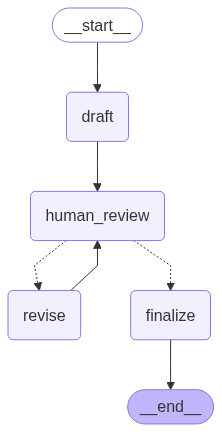

In [2]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod


graph = create_hitl_graph()
display(
    Image(
        graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [ ]:

# Usage example
if __name__ == "__main__":
    # Create the workflow
    workflow = create_hitl_graph()
    
    # Initial state with a user question
    initial_state = {
        "question": "What's the best way to implement HITL systems?",
        "ai_draft": "",
        "human_feedback": "",
        "final_response": ""
    }
    
    # Run the workflow
    for output in workflow.stream(initial_state):
        # In a production application, you would handle these events appropriately
        print(output)
        
    # Final state contains the complete conversation
    print("\n=== WORKFLOW COMPLETED ===")



🤖 AI has drafted a response: DRAFT: Here's my initial answer to: 'What's the best way to implement HITL systems?'

{'draft': {'ai_draft': "DRAFT: Here's my initial answer to: 'What's the best way to implement HITL systems?'"}}

👋 HUMAN REVIEW REQUIRED!

Original question: What's the best way to implement HITL systems?
AI draft: DRAFT: Here's my initial answer to: 'What's the best way to implement HITL systems?'


In [4]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command, interrupt
from langchain_core.tools import tool
from typing import TypedDict, Optional, Literal
import re

# === Define custom state schema ===
class HumanInTheLoopState(TypedDict):
    question: str
    ai_draft: str
    human_feedback: Optional[str]
    final_response: Optional[str]
    moderation_result: Optional[dict]
    rejection_reason: Optional[str]

BANNED_WORDS = ["vulgar", "offensive", "banned"]

# === Tools ===
@tool
def publish_content(content: str):
    """Publishes the final AI content after approval."""
    print("✅ Published:", content)
    return "Published"

@tool
def reject_content(reason: str):
    """Rejects the content and logs the reason."""
    print("❌ Rejected:", reason)
    return f"Rejected: {reason}"



# === Node: AI Moderation ===
def ai_moderation_node(state: HumanInTheLoopState):
    draft = state["ai_draft"]
    issues = [word for word in BANNED_WORDS if re.search(rf"\b{word}\b", draft, re.IGNORECASE)]

    if issues:
        return {"moderation_result": {"status": "flagged", "issues": issues}}
    else:
        return {"moderation_result": {"status": "clean"}}


# === Node: Human Review ===
def human_review_node(state: HumanInTheLoopState) -> Command[Literal["publish", "reject", "moderate"]]:
    draft = state["ai_draft"]
    issues = state["moderation_result"]["issues"]

    review = interrupt({
        "question": f"Content flagged for: {issues}. Approve, update, or reject?",
        "content": draft
    })

    action = review["action"]

    if action == "approve":
        return Command(goto="publish")

    elif action == "update":
        updated = review["updated_content"]
        return Command(goto="moderate", update={"ai_draft": updated, "human_feedback": "Updated by human"})

    elif action == "reject":
        return Command(goto="reject", update={"rejection_reason": review.get("reason", "No reason provided")})


# === Route Logic ===
def route_after_moderation(state: HumanInTheLoopState) -> Literal["publish", "human_review_node"]:
    return "publish" if state["moderation_result"]["status"] == "clean" else "human_review_node"


# === Node: Publish ===
def publish_node(state: HumanInTheLoopState):
    return {"final_response": publish_content(state["ai_draft"])}


# === Node: Reject ===
def reject_node(state: HumanInTheLoopState):
    return {"final_response": reject_content(state["rejection_reason"])}


# === Build the Graph ===
builder = StateGraph(HumanInTheLoopState)

builder.add_node("moderate", ai_moderation_node)
builder.add_node("publish", publish_node)
builder.add_node("reject", reject_node)
builder.add_node("human_review_node", human_review_node)

builder.add_conditional_edges("moderate", route_after_moderation)
builder.add_edge("human_review_node", "moderate")
builder.set_entry_point("moderate")

graph = builder.compile(checkpointer=MemorySaver())


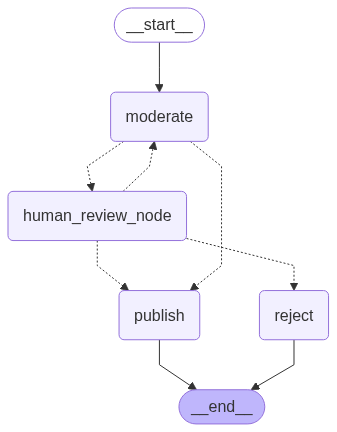

In [5]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

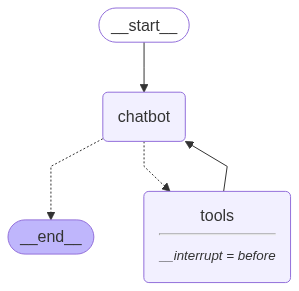

In [1]:
from dotenv import load_dotenv

load_dotenv()
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph.message import add_messages


class State(TypedDict):
    messages: Annotated[list, add_messages]
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.tools import tool

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph
from langgraph.prebuilt import ToolNode, tools_condition

checkpointer = MemorySaver()

graph_builder = StateGraph(State)


@tool
def get_weather(location: str):
    """Call to get the current weather."""
    if location.lower() in ["munich"]:
        return "It's 15 degrees Celsius and cloudy."
    else:
        return "It's 32 degrees Celsius and sunny."


@tool
def broken_api(location: str):
    """Call to get the current weather."""
    return f"Currently no weather data available for {location}. Please try again later"


tools = [get_weather, broken_api]
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
llm_with_tools = llm.bind_tools(tools)


def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}
graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
graph_builder.add_edge("tools", "chatbot")
graph_builder.set_entry_point("chatbot")
graph = graph_builder.compile(
    checkpointer=checkpointer,
    interrupt_before=["tools"],
)
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


In [2]:
from langchain_core.messages import HumanMessage

config = {"configurable": {"thread_id": "1"}}
input_message = HumanMessage(content="Hello, I am John")

graph.invoke({"messages": input_message}, config=config)



{'messages': [HumanMessage(content='Hello, I am John', additional_kwargs={}, response_metadata={}, id='19deb840-6816-4401-8088-dbdc5db6b701'),
  AIMessage(content='Hello John, how can I help you today?', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--f93223e7-9b9d-4618-9723-19df12aac349-0', usage_metadata={'input_tokens': 84, 'output_tokens': 10, 'total_tokens': 94, 'input_token_details': {'cache_read': 0}})]}

In [3]:
print(graph.get_state(config).next)

()


In [4]:
config = {"configurable": {"thread_id": "2"}}
input_message = HumanMessage(content="Sorry, did I already introduce myself?")

graph.invoke({"messages": input_message}, config=config)


{'messages': [HumanMessage(content='Sorry, did I already introduce myself?', additional_kwargs={}, response_metadata={}, id='519de04d-283c-4b62-b9fe-a441f362da00'),
  AIMessage(content="I don't have memory of past conversations, so I wouldn't know if you've introduced yourself before.", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--4c2f4b37-2f3d-446a-a3da-b2a01546fdb9-0', usage_metadata={'input_tokens': 87, 'output_tokens': 24, 'total_tokens': 176, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 65}})]}

In [5]:
print(graph.get_state(config).next)

()


In [6]:
config = {"configurable": {"thread_id": "1"}}
input_message = HumanMessage(content="Sorry, did I already introduce myself?")

graph.invoke({"messages": input_message}, config=config)



{'messages': [HumanMessage(content='Hello, I am John', additional_kwargs={}, response_metadata={}, id='19deb840-6816-4401-8088-dbdc5db6b701'),
  AIMessage(content='Hello John, how can I help you today?', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--f93223e7-9b9d-4618-9723-19df12aac349-0', usage_metadata={'input_tokens': 84, 'output_tokens': 10, 'total_tokens': 94, 'input_token_details': {'cache_read': 0}}),
  HumanMessage(content='Sorry, did I already introduce myself?', additional_kwargs={}, response_metadata={}, id='79a11418-1d19-4e7a-be8a-70320780fd51'),
  AIMessage(content='Yes, you did. You said your name is John.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--add32d19-369d-4737-a8f1-f0bd

In [7]:
snapshot = graph.get_state(config)
snapshot.next

()

In [8]:
from langchain_core.messages import HumanMessage

config = {"configurable": {"thread_id": "3"}}
input_message = HumanMessage(content="How is the weather in Munich?")

graph.invoke({"messages": input_message}, config=config)


{'messages': [HumanMessage(content='How is the weather in Munich?', additional_kwargs={}, response_metadata={}, id='4fd73866-1c4f-4fbd-9b9a-f060abbc9eda'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"location": "Munich"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--3aa3bf58-2629-4850-91e1-c1c7b67d50c3-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Munich'}, 'id': '7acd6538-2fac-47d4-9132-38ecb55c31c2', 'type': 'tool_call'}], usage_metadata={'input_tokens': 86, 'output_tokens': 16, 'total_tokens': 142, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 40}})]}

In [9]:
print(graph.get_state(config).next)

('tools',)


In [10]:
snapshot = graph.get_state(config)
snapshot.next


('tools',)

In [11]:
graph.invoke(None, config=config)

{'messages': [HumanMessage(content='How is the weather in Munich?', additional_kwargs={}, response_metadata={}, id='4fd73866-1c4f-4fbd-9b9a-f060abbc9eda'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"location": "Munich"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--3aa3bf58-2629-4850-91e1-c1c7b67d50c3-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Munich'}, 'id': '7acd6538-2fac-47d4-9132-38ecb55c31c2', 'type': 'tool_call'}], usage_metadata={'input_tokens': 86, 'output_tokens': 16, 'total_tokens': 142, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 40}}),
  ToolMessage(content="It's 15 degrees Celsius and cloudy.", name='get_weather', id='9453d82e-baf3-4afb-8721-e8b4d26d851a', tool_call_id='7acd6538-2fac-47d4-9132-38ecb55c31c2'),
  AIMessage(content="It's 

In [12]:
from langchain_core.messages import HumanMessage

config = {"configurable": {"thread_id": "4"}}
input_message = HumanMessage(content="How is the weather in Munich?")

graph.invoke({"messages": input_message}, config=config)

{'messages': [HumanMessage(content='How is the weather in Munich?', additional_kwargs={}, response_metadata={}, id='d9b6dade-aa67-433c-b05e-90703c77e039'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"location": "Munich"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--14d92d6e-49a4-4b4b-8b6e-5ccc5cabd577-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Munich'}, 'id': 'df1994b7-2ef0-4cd8-a411-fa38657c1dfb', 'type': 'tool_call'}], usage_metadata={'input_tokens': 86, 'output_tokens': 16, 'total_tokens': 145, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 43}})]}

In [13]:
snapshot = graph.get_state(config)
existing_message = snapshot.values["messages"][-1]
existing_message.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  get_weather (df1994b7-2ef0-4cd8-a411-fa38657c1dfb)
 Call ID: df1994b7-2ef0-4cd8-a411-fa38657c1dfb
  Args:
    location: Munich


In [14]:
from langchain_core.messages import AIMessage, ToolMessage

answer = "It is only 5°C warm today!"
new_messages = [
    ToolMessage(content=answer, tool_call_id=existing_message.tool_calls[0]["id"]),
    AIMessage(content=answer),
]
graph.update_state(
    config,
    {"messages": new_messages},
)

{'configurable': {'thread_id': '4',
  'checkpoint_ns': '',
  'checkpoint_id': '1f056335-c5a9-6c68-8002-d9d2ed5d71b1'}}

In [15]:
print((graph.get_state(config).values["messages"]))

[HumanMessage(content='How is the weather in Munich?', additional_kwargs={}, response_metadata={}, id='d9b6dade-aa67-433c-b05e-90703c77e039'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"location": "Munich"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--14d92d6e-49a4-4b4b-8b6e-5ccc5cabd577-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Munich'}, 'id': 'df1994b7-2ef0-4cd8-a411-fa38657c1dfb', 'type': 'tool_call'}], usage_metadata={'input_tokens': 86, 'output_tokens': 16, 'total_tokens': 145, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 43}}), ToolMessage(content='It is only 5°C warm today!', id='5b9b1a93-cf64-4904-9f3e-b475504dfecb', tool_call_id='df1994b7-2ef0-4cd8-a411-fa38657c1dfb'), AIMessage(content='It is only 5°C warm today!', additional_kwargs={}, re

In [16]:
config = {"configurable": {"thread_id": "4"}}
input_message = HumanMessage(content="How warm was it again?")

graph.invoke({"messages": input_message}, config=config)

{'messages': [HumanMessage(content='How is the weather in Munich?', additional_kwargs={}, response_metadata={}, id='d9b6dade-aa67-433c-b05e-90703c77e039'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"location": "Munich"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--14d92d6e-49a4-4b4b-8b6e-5ccc5cabd577-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Munich'}, 'id': 'df1994b7-2ef0-4cd8-a411-fa38657c1dfb', 'type': 'tool_call'}], usage_metadata={'input_tokens': 86, 'output_tokens': 16, 'total_tokens': 145, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 43}}),
  ToolMessage(content='It is only 5°C warm today!', id='5b9b1a93-cf64-4904-9f3e-b475504dfecb', tool_call_id='df1994b7-2ef0-4cd8-a411-fa38657c1dfb'),
  AIMessage(content='It is only 5°C warm today!', addit

In [17]:
all_checkpoints = []
for state in graph.get_state_history(config=config):
    all_checkpoints.append(state)
all_checkpoints

[StateSnapshot(values={'messages': [HumanMessage(content='How is the weather in Munich?', additional_kwargs={}, response_metadata={}, id='d9b6dade-aa67-433c-b05e-90703c77e039'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"location": "Munich"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--14d92d6e-49a4-4b4b-8b6e-5ccc5cabd577-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Munich'}, 'id': 'df1994b7-2ef0-4cd8-a411-fa38657c1dfb', 'type': 'tool_call'}], usage_metadata={'input_tokens': 86, 'output_tokens': 16, 'total_tokens': 145, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 43}}), ToolMessage(content='It is only 5°C warm today!', id='5b9b1a93-cf64-4904-9f3e-b475504dfecb', tool_call_id='df1994b7-2ef0-4cd8-a411-fa38657c1dfb'), AIMessage(content='It is only 5°C war

In [18]:
to_replay = all_checkpoints[4]
to_replay.values

{'messages': [HumanMessage(content='How is the weather in Munich?', additional_kwargs={}, response_metadata={}, id='d9b6dade-aa67-433c-b05e-90703c77e039'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"location": "Munich"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--14d92d6e-49a4-4b4b-8b6e-5ccc5cabd577-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Munich'}, 'id': 'df1994b7-2ef0-4cd8-a411-fa38657c1dfb', 'type': 'tool_call'}], usage_metadata={'input_tokens': 86, 'output_tokens': 16, 'total_tokens': 145, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 43}})]}

In [19]:
to_replay.next

('tools',)

In [20]:
to_replay.config

{'configurable': {'thread_id': '4',
  'checkpoint_ns': '',
  'checkpoint_id': '1f056333-eaf3-6eda-8001-2494d7a6e4ff'}}

In [21]:
graph.invoke(None, config=to_replay.config)

{'messages': [HumanMessage(content='How is the weather in Munich?', additional_kwargs={}, response_metadata={}, id='d9b6dade-aa67-433c-b05e-90703c77e039'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"location": "Munich"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--14d92d6e-49a4-4b4b-8b6e-5ccc5cabd577-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Munich'}, 'id': 'df1994b7-2ef0-4cd8-a411-fa38657c1dfb', 'type': 'tool_call'}], usage_metadata={'input_tokens': 86, 'output_tokens': 16, 'total_tokens': 145, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 43}}),
  ToolMessage(content="It's 15 degrees Celsius and cloudy.", name='get_weather', id='b05a5f21-9b44-4920-aa55-4d17472643dc', tool_call_id='df1994b7-2ef0-4cd8-a411-fa38657c1dfb'),
  AIMessage(content="It's 

In [ ]:
from typing_extensions import Literal
from langgraph.graph import StateGraph, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command, interrupt
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.tools import tool
# from langgraph.graph.message import ToolNode
from langgraph.prebuilt import ToolNode
import re

import dotenv

dotenv.load_dotenv()


# === RESTRICTED TOPICS ===
RESTRICTED_TOPICS = ["violence", "murder", "sex", "drugs", "death", "blood", "war"]


# === TOOL: Publish Story ===
@tool
def publish_story(story: str):
    """Publishes the approved story for kids."""
    print("✅ Published Story:\n", story)
    return "Story published!"


# === LLM Model (Bound to the publish tool) ===
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash").bind_tools([publish_story])


# === Node: Generate Story ===
def generate_story(state):
    return {"messages": [model.invoke(state["messages"])]}


# === Node: Check for restricted content ===
def route_after_story(state) -> Literal["human_review_node", "run_tool"]:
    story = state["messages"][-1].content.lower()
    if any(bad_word in story for bad_word in RESTRICTED_TOPICS):
        return "human_review_node"
    return "run_tool"


# === Node: Human-in-the-loop review ===
def human_review_node(state) -> Command[Literal["run_tool", "reject_story_node"]]:
    last_message = state["messages"][-1]
    tool_call = last_message.tool_calls[-1]

    review = interrupt({
        "question": "Should we publish this story?",
        "tool_call": tool_call,
    })

    action = review["action"]
    data = review.get("data")

    if action == "continue":
        return Command(goto="run_tool")

    elif action == "update":
        updated_tool_call = {
            "role": "ai",
            "content": last_message.content,
            "tool_calls": [
                {
                    "id": tool_call["id"],
                    "name": tool_call["name"],
                    "args": data,
                }
            ],
            "id": last_message.id,
        }
        return Command(goto="run_tool", update={"messages": [updated_tool_call]})

    elif action == "reject":
        return Command(goto=END, update={"messages": state["messages"] + [AIMessage(content="❌ Story rejected by human.")]})


# === Node: If restricted, end early ===
def reject_story_node(state):
    return {"messages": state["messages"] + [AIMessage(content="❌ This story topic is not appropriate for kids and has been rejected.")]}


In [5]:
builder = StateGraph(MessagesState)

tools = ToolNode(tools=[publish_story])

builder.add_node("call_llm", generate_story)
builder.add_node("run_tool", tools)
builder.add_node("human_review_node", human_review_node)
builder.add_node("reject_story_node", reject_story_node)



builder.add_conditional_edges("call_llm", route_after_story)
builder.add_edge("human_review_node", "run_tool")

builder.add_edge("run_tool", END)
builder.add_edge("reject_story_node", END)

builder.set_entry_point("call_llm")

graph = builder.compile(checkpointer=MemorySaver())


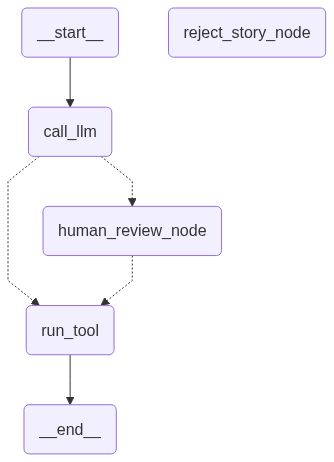

In [6]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

# ✅ Test Case 1: Clean Topic → Approve and Publish


In [ ]:
initial_input = {
    "messages": [
        HumanMessage(content="Tell me a story on two kinds playing in the garden.")
    ]
}

config = {"configurable": {"thread_id": "story-approve"}}
graph.invoke(initial_input, config=config, stream_mode="updates")

[{'call_llm': {'messages': [AIMessage(content='Once upon a time, in a cozy cave filled with glittering gems and warm light, lived a friendly dragon named Sparky. Sparky wasn\'t like other dragons who hoarded gold; he hoarded numbers! He loved math more than anything and wanted to share his passion with the world.\n\nOne sunny morning, a group of curious children ventured near Sparky\'s cave. They were a little scared at first, but Sparky\'s gentle smile and twinkling eyes put them at ease. "Hello, little friends!" Sparky rumbled, "Do you want to play a game with numbers?"\n\nThe children, intrigued, nodded. Sparky then began to tell them stories, but each story had a math problem hidden within it. "If I have three shiny scales and two more grow today, how many scales do I have?" he\'d ask. The children giggled as they counted on their fingers and shouted, "Five!"\n\nSparky taught them about addition using the number of stars in the night sky, subtraction with the cookies they shared, m

In [5]:
graph.get_state(config).next

()

In [ ]:
from typing_extensions import Literal
from langgraph.graph import StateGraph, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command, interrupt
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
import re
import dotenv

dotenv.load_dotenv()

# === RESTRICTED TOPICS ===
RESTRICTED_TOPICS = ["violence", "murder", "sex", "drugs", "death", "blood", "war"]


# === TOOL: Publish Story ===
@tool
def publish_story(story: str):
    """Publishes the approved story for kids."""
    print("✅ Published Story:\n", story)
    return "Story published!"


# === TOOL: Fetch Story ===
@tool
def fetch_story(topic: str) -> str:
    """Returns a short story based on the given topic."""
    stories = {
        "sharing": (
            "Once upon a time, a bunny named Benny found a big bunch of carrots. "
            "Instead of keeping them all, he shared them with his forest friends. "
            "Everyone celebrated Benny's kindness and they had a joyful carrot feast together!"
        ),
        "kindness": (
            "In a sunny village, a young girl named Lila helped an old man carry his groceries. "
            "The man smiled and gave her a shiny marble as a thank-you. "
            "Lila's kind heart inspired the whole village to start a kindness club!"
        ),
        "honesty": (
            "A boy named Omar accidentally broke a neighbor’s window. He was scared but told the truth. "
            "The neighbor thanked him for being honest and fixed it together with Omar. "
            "From then on, Omar became known as the most trustworthy kid in town."
        ),
        # 🚨 Forbidden story for testing moderation
        "violence": (
            "In a dark kingdom, warriors trained daily in brutal combat. "
            "They fought with swords, spilled blood in the arena, and sought power through violence and fear."
        ),
    }

    return stories.get(topic.lower(), "Sorry, no story is available for this topic.")



# === LLM Setup ===
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash").bind_tools(
    [fetch_story, publish_story]
)


# === Node: Generate Story via tool call ===
def call_llm(state):
    prompt="""if the question contains forbitten topic, return True or return False"""
    return {"messages": [model.invoke(prompt+ state["messages"])]}

def reject_story_node(state):
    return {
        "messages": state["messages"] + [
            AIMessage(content="❌ This story contains restricted content and has been automatically rejected.")
        ]
    }


# === Router: Check if content has restricted topics ===
def route_after_llm(state) -> Literal["reject_story_node", "human_review_node"]:
    story = state["messages"][-1].content.lower()
    if any(re.search(rf"\b{word}\b", story) for word in RESTRICTED_TOPICS):
        return "reject_story_node"  # Hard rejection if forbidden word is matched exactly
    return "call_tool"  # Otherwise send to human review

def route_after_tool(state) -> Literal["reject_story_node", "human_review_node"]:
    story = state["messages"][-1].content.lower()
    if any(re.search(rf"\b{word}\b", story) for word in RESTRICTED_TOPICS):
        return "reject_story_node"  # Hard rejection if forbidden word is matched exactly
    return "call_tool"  # Otherwise send to human review

# === Human Review Node ===
def human_review_node(state) -> Command[Literal[END, "run_tool"]]:
    last_message = state["messages"][-1]
    tool_call = last_message.tool_calls[-1]

    review = interrupt({
        "question": "Do you want to publish this story?",
        "tool_call": tool_call
    })

    action = review["action"]
    data = review.get("data")

    if action == "continue":
        return Command(goto="run_tool")

    elif action == "update":
        updated_message = {
            "role": "ai",
            "content": last_message.content,
            "tool_calls": [{
                "id": tool_call["id"],
                "name": tool_call["name"],
                "args": data,
            }],
            "id": last_message.id,
        }
        return Command(goto="run_tool", update={"messages": [updated_message]})

    elif action == "reject":
        return Command(goto=END, update={
            "messages": state["messages"] + [AIMessage(content="❌ Story rejected by human.")]
        })


In [ ]:
builder = StateGraph(MessagesState)

tools = ToolNode(tools=[fetch_story, publish_story])
builder.add_node("call_llm", call_llm)
builder.add_node("run_tool", tools)
builder.add_node("human_review_node", human_review_node)
builder.add_node("reject_story_node", reject_story_node)


builder.add_conditional_edges("call_llm", route_after_llm)
builder.add_edge("call_llm", "run_tool")
builder.add_edge("run_tool", "human_review_node")
builder.add_edge("reject_story_node", END)

builder.set_entry_point("call_llm")

graph = builder.compile(checkpointer=MemorySaver())


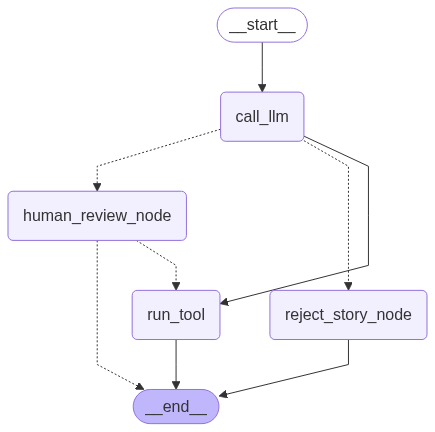

In [ ]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [4]:
initial_input = {
    "messages": [HumanMessage(content="Tell me a story about kindness")]
}
config = {"configurable": {"thread_id": "test-approve"}}

# Step 1: Invoke story generation
graph.invoke(initial_input, config=config, stream_mode="updates")




[{'call_llm': {'messages': [AIMessage(content='', additional_kwargs={'function_call': {'name': 'fetch_story', 'arguments': '{"topic": "kindness"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--4d98540a-2e62-4831-b1da-88b79f2d1ba6-0', tool_calls=[{'name': 'fetch_story', 'args': {'topic': 'kindness'}, 'id': '0e161c60-7907-42da-bf04-c06fdaa79d3e', 'type': 'tool_call'}], usage_metadata={'input_tokens': 89, 'output_tokens': 16, 'total_tokens': 188, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 83}})]}},
 {'__interrupt__': (Interrupt(value={'question': 'Do you want to publish this story?', 'tool_call': {'name': 'fetch_story', 'args': {'topic': 'kindness'}, 'id': '0e161c60-7907-42da-bf04-c06fdaa79d3e', 'type': 'tool_call'}}, resumable=True, ns=['human_review_node:19585a3a-885e-3651-f944-32ecb30c1f77']),)}]

In [ ]:
# Step 2: Human approves
graph.invoke(Command(resume={"action": "continue"}), config=config)

In [ ]:
from typing_extensions import Literal
from langgraph.graph import StateGraph, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command, interrupt
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
import dotenv

dotenv.load_dotenv()

# === Forbidden Topics ===
FORBIDDEN_TOPICS = ["violence", "murder", "sex", "drugs", "death", "blood", "war"]

# === TOOL: Fetch Story ===
@tool
def fetch_story(topic: str) -> str:
    """Returns a short story based on the given topic."""
    stories = {
        "sharing": "Benny the bunny shared his carrots and made everyone happy!",
        "kindness": "Lila helped an old man and started a kindness club!",
        "honesty": "Omar admitted his mistake and became trustworthy.",
        "violence": "Warriors fought in blood-soaked battles... (🚫 not for kids!)"
    }
    return stories.get(topic.lower(), "Sorry, no story is available for this topic.")

# === Model with Tools ===
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash").bind_tools(
    [fetch_story]
)

# === Step 1: Topic Moderation ===
def moderate_topic_node(state):
    question = state["messages"][-1].content
    prompt = (
        f"Return `true` if the following question is about any of these topics: "
        f"{', '.join(FORBIDDEN_TOPICS)}. Else return False.\n\nQuestion: {question}"
    )
    result = model.invoke(prompt).content.strip().lower()
    return {"messages": state["messages"] + [AIMessage(content=result)]}

def generate_story(state):
    messages = state["messages"]
    prompt = f"""Call tool for the story..
    
    user request: {messages}"""
    
    response = model.invoke(prompt)
    return {"messages": response}

# def refine_story(state):
#     messages = state["messages"][-1].content 
#     prompt =f"""If user ask for update then only use your intellegence to response with the updated story

#     user request: {messages}

#     """
#     response = model.invoke(prompt)
#     return {"messages": response}



# === Step 2: Route Based on Moderation ===
def route_after_moderation(state) -> Literal["reject_story_node", "call_tool"]:
    result = state["messages"][-1].content.strip().lower()
    if "true" in result:
        return "reject_story_node"
    return "generate_story"


# === Step 3: Generate Story ===
def reject_story_node(state):
    if state["messages"][-1].content == "Story rejected by human":
        return {
            "messages": ["❌ "] + [state["messages"][-1]]
        }
    else:
        return {
            "messages": [
                AIMessage(content="❌ This topic is not suitable for kids and has been rejected.")
            ]
        }

def should_continue(state):
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "call_tool"
    return "human_review_node"

# === Step 4: Route After Story ===
def route_after_tool(state) -> Literal["reject_story_node", "human_review_node"]:
    story = state["messages"][-1].content.lower()
    if any(word in story for word in FORBIDDEN_TOPICS):
        return "reject_story_node"
    return "human_review_node"

def publish(state):
    # print(f"the story: `{state["messages"][-1].content}` is published!")
    return {
        "messages": state["messages"] + [
            AIMessage(content=f"This `{state["messages"][-1].content}` is pubished!.")
        ]
    }


# === Step 5: Human Review ===
def human_review_node(state) -> Command[Literal[END, "generate_story", "reject_story_node"]]:
    last_message = state["messages"][-1]
    # tool_call = last_message.tool_calls[-1]

    review = interrupt({
        "question": "Do you want to publish this story?",
        "story": last_message
    })

    action = review["action"]
    data = review.get("data")

    if action == "publish":
        print("Published")
       
        return Command(goto=END)
    
    elif action == "update":

        update_with = data.get("corrections", "")

        return Command(goto="generate_story", update={
            "messages": state["messages"] + [HumanMessage(content=f"update with {update_with}")]
        })

    elif action == "reject":
        return Command(goto="reject_story_node", update={
            "messages": state["messages"] + [AIMessage(content="Story rejected by human")]
        })
        #  return Command(goto="reject_story_node")

# === Build Graph ===
builder = StateGraph(MessagesState)

tools = ToolNode(tools=[fetch_story])

builder.add_node("moderate_topic", moderate_topic_node)
builder.add_node("call_tool", tools)
builder.add_node("reject_story_node", reject_story_node)
builder.add_node("human_review_node", human_review_node)
builder.add_node("generate_story", generate_story)
# builder.add_node("publish", publish)
# builder.add_node("refine_story", refine_story)

builder.set_entry_point("moderate_topic")
builder.add_conditional_edges("moderate_topic", route_after_moderation, {"reject_story_node":"reject_story_node", "generate_story":"generate_story"})
builder.add_conditional_edges("generate_story", should_continue, {"call_tool":"call_tool", "human_review_node":"human_review_node"})
builder.add_edge("generate_story", "human_review_node")
builder.add_edge("call_tool", "generate_story")
# builder.add_edge("publish", END)

builder.add_edge("reject_story_node", END)

graph = builder.compile(checkpointer=MemorySaver())


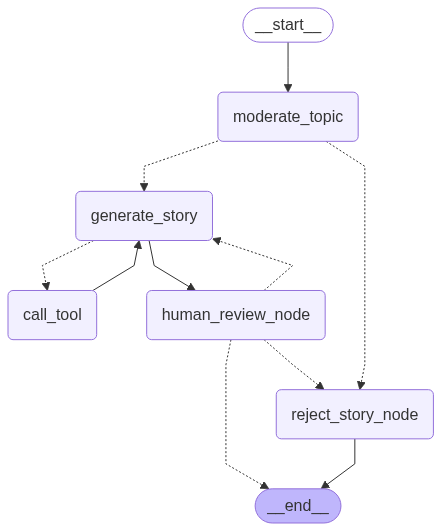

In [30]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        graph.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [31]:
from langchain_core.messages import HumanMessage
from langgraph.types import Command

# Step 1: Ask for a valid topic
config = {"configurable": {"thread_id": "case-approve"}}
initial_input = {"messages": [HumanMessage(content="Can you tell me a story about kindness?")]}
graph.invoke(initial_input, config=config, stream_mode="updates")

[{'moderate_topic': {'messages': [HumanMessage(content='Can you tell me a story about kindness?', additional_kwargs={}, response_metadata={}, id='acd53922-000b-4e63-ba7d-331f7b9b726c'),
    AIMessage(content='false', additional_kwargs={}, response_metadata={}, id='3fc5de52-dab7-4c84-9246-6906800e55d3')]}},
 {'generate_story': {'messages': AIMessage(content='', additional_kwargs={'function_call': {'name': 'fetch_story', 'arguments': '{"topic": "kindness"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--6a92f81a-43f5-4be7-8dd7-c9afb4dd68d6-0', tool_calls=[{'name': 'fetch_story', 'args': {'topic': 'kindness'}, 'id': '427e7246-0a97-40bf-b087-7cc163da1e35', 'type': 'tool_call'}], usage_metadata={'input_tokens': 163, 'output_tokens': 16, 'total_tokens': 226, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 47}})}},
 {'__interrupt__': (

In [32]:
graph.get_state(config).next

('human_review_node',)

In [33]:
# Step 2: Human approves (publishes the story)
graph.invoke(Command(resume={"action": "publish"}), config=config)

Published


{'messages': [HumanMessage(content='Can you tell me a story about kindness?', additional_kwargs={}, response_metadata={}, id='acd53922-000b-4e63-ba7d-331f7b9b726c'),
  AIMessage(content='false', additional_kwargs={}, response_metadata={}, id='3fc5de52-dab7-4c84-9246-6906800e55d3'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'fetch_story', 'arguments': '{"topic": "kindness"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--6a92f81a-43f5-4be7-8dd7-c9afb4dd68d6-0', tool_calls=[{'name': 'fetch_story', 'args': {'topic': 'kindness'}, 'id': '427e7246-0a97-40bf-b087-7cc163da1e35', 'type': 'tool_call'}], usage_metadata={'input_tokens': 163, 'output_tokens': 16, 'total_tokens': 226, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 47}}),
  ToolMessage(content='Lila helped an old man and started a kindness club!', n

In [11]:
graph.get_state(config).next

()

In [12]:
config = {"configurable": {"thread_id": "case-update"}}
initial_input = {"messages": [HumanMessage(content="Tell me a story about honesty")]}
graph.invoke(initial_input, config=config, stream_mode="updates")

[{'moderate_topic': {'messages': [HumanMessage(content='Tell me a story about honesty', additional_kwargs={}, response_metadata={}, id='52552121-df3b-45ed-a141-62963ad480a9'),
    AIMessage(content='false', additional_kwargs={}, response_metadata={}, id='3f057855-2c16-4972-924b-738809fc1d65')]}},
 {'generate_story': {'messages': AIMessage(content='', additional_kwargs={'function_call': {'name': 'fetch_story', 'arguments': '{"topic": "honesty"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--539cc59e-3032-476c-951d-7aa26affe71b-0', tool_calls=[{'name': 'fetch_story', 'args': {'topic': 'honesty'}, 'id': '38ff43a8-6647-4de5-b314-87e108715600', 'type': 'tool_call'}], usage_metadata={'input_tokens': 60, 'output_tokens': 16, 'total_tokens': 127, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 51}})}},
 {'call_tool': {'messages': [Tool

In [13]:
graph.get_state(config).next

('human_review_node',)

In [14]:
# Step 2: Human updates the story (e.g., modifies content)
graph.invoke(Command(resume={
    "action": "update",
     "data": {"corrections": "Omar became trustworthy after admitting his mistake."
              },
}), config=config)


{'messages': [HumanMessage(content='Tell me a story about honesty', additional_kwargs={}, response_metadata={}, id='52552121-df3b-45ed-a141-62963ad480a9'),
  AIMessage(content='false', additional_kwargs={}, response_metadata={}, id='3f057855-2c16-4972-924b-738809fc1d65'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'fetch_story', 'arguments': '{"topic": "honesty"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--539cc59e-3032-476c-951d-7aa26affe71b-0', tool_calls=[{'name': 'fetch_story', 'args': {'topic': 'honesty'}, 'id': '38ff43a8-6647-4de5-b314-87e108715600', 'type': 'tool_call'}], usage_metadata={'input_tokens': 60, 'output_tokens': 16, 'total_tokens': 127, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 51}}),
  ToolMessage(content='Omar admitted his mistake and became trustworthy.', name='fetch_stor

In [15]:

graph.get_state(config).next


('human_review_node',)

In [11]:
# Step 2: Human approves (publishes the story)
graph.invoke(Command(resume={"action": "publish"}), config=config)

{'messages': [HumanMessage(content='Tell me a story about honesty', additional_kwargs={}, response_metadata={}, id='5daa8076-93a6-48ab-a93b-5dd0d4653b52'),
  AIMessage(content='false', additional_kwargs={}, response_metadata={}, id='88f3b5f9-8b07-49e2-ba4e-176da60d2b63'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'fetch_story', 'arguments': '{"topic": "honesty"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--c9647bc6-c081-406c-bb53-0ad38f4bfaae-0', tool_calls=[{'name': 'fetch_story', 'args': {'topic': 'honesty'}, 'id': '25403696-ab93-4344-aad5-82d327d9fd01', 'type': 'tool_call'}], usage_metadata={'input_tokens': 190, 'output_tokens': 16, 'total_tokens': 284, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 78}}),
  ToolMessage(content='Omar admitted his mistake and became trustworthy.', name='fetch_sto

In [8]:
graph.invoke(Command(resume={"action": "reject"}), config=config)

{'messages': [HumanMessage(content='Tell me a story about violance', additional_kwargs={}, response_metadata={}, id='647662b0-ea31-4105-9b87-c8305e41ed73'),
  AIMessage(content='true', additional_kwargs={}, response_metadata={}, id='4ff5410b-79a6-42f0-9a0c-1fe8c2781bbd'),
  AIMessage(content='❌ This topic is not suitable for kids and has been rejected.', additional_kwargs={}, response_metadata={}, id='c9de0d29-4767-4965-ac56-139bcd3e8747'),
  HumanMessage(content='Tell me a story about honesty', additional_kwargs={}, response_metadata={}, id='5460ed5b-163d-4de2-86a7-315bebe9637e'),
  AIMessage(content='false', additional_kwargs={}, response_metadata={}, id='e0a04bab-cc35-49d4-a1d2-7929695d6858'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'fetch_story', 'arguments': '{"topic": "honesty"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run-

In [3]:
config = {"configurable": {"thread_id": "case-update"}}
initial_input = {"messages": [HumanMessage(content="Tell me a story about violance")]}
graph.invoke(initial_input, config=config, stream_mode="updates")

[{'moderate_topic': {'messages': [HumanMessage(content='Tell me a story about violance', additional_kwargs={}, response_metadata={}, id='647662b0-ea31-4105-9b87-c8305e41ed73'),
    AIMessage(content='true', additional_kwargs={}, response_metadata={}, id='4ff5410b-79a6-42f0-9a0c-1fe8c2781bbd')]}},
 {'reject_story_node': {'messages': [AIMessage(content='❌ This topic is not suitable for kids and has been rejected.', additional_kwargs={}, response_metadata={}, id='c9de0d29-4767-4965-ac56-139bcd3e8747')]}}]